Note: sierras_gdf_2018_2021_atl06_01312026_processed.pkl used linear sampling for the reanalysis variables. sierras_gdf_2018_2021_sa_processed.pkl used nearest neighbor.

In [1]:
import numpy as np 
import pandas as pd 
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import rioxarray as rxr
import pickle
from astropy.time import Time
from pathlib import Path

### Load ICESat-2 data downloaded over Sierra Nevada:

In [2]:
atl06sr_gdf = pickle.load(open('../data/icesat2/sierras_gdf_2018_2021_atl06_01312026.pkl', 'rb'))
atl06sr_gdf

,pflags,x_atc,h_mean,gt,dh_fit_dx,n_fit_photons,spot,region,cycle,h_sigma,...,segment_watermask,urban_flag,3dep.aspect,3dep.flags,3dep.time,3dep.count,3dep.value,3dep.slope,3dep.file_id,water_year
time,,,,,,,,,,,,,,,,,,,,,
2018-10-14 11:40:32.488605184,0,15659863.0,1518.346291,50,0.011479,20,2,region_4_north,1,0.075959,...,0.0,0.0,232.052131,0,1.354129e+09,9,1519.330275,1.426646,25769803776,wy2019
2018-10-14 11:40:32.491426304,0,15659883.0,1518.495766,50,0.002426,26,2,region_4_north,1,0.061681,...,0.0,0.0,233.839987,0,1.354129e+09,9,1518.552762,3.227037,25769803776,wy2019
2018-10-14 11:40:32.494251264,0,15659903.0,1518.744404,50,0.019836,32,2,region_4_north,1,0.037445,...,0.0,0.0,78.941624,0,1.354129e+09,9,1518.741193,2.125614,25769803776,wy2019
2018-10-14 11:40:32.497075456,0,15659923.0,1518.924909,50,-0.002168,34,2,region_4_north,1,0.033904,...,0.0,0.0,195.925239,0,1.354129e+09,9,1518.743467,1.243357,25769803776,wy2019
2018-10-14 11:40:32.499896576,0,15659943.0,1518.817927,50,-0.006208,36,2,region_4_north,1,0.047438,...,0.0,0.0,129.684062,0,1.354129e+09,9,1518.892104,0.707748,25769803776,wy2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-09-30 07:56:02.104347136,0,16052711.0,226.890584,40,-0.054218,20,3,region_1_south,13,0.076027,...,0.0,0.0,282.249086,0,1.354129e+09,9,226.117328,3.056535,73014444032,wy2021
2021-09-30 07:56:02.107133952,0,16052731.0,225.671663,40,-0.069895,20,3,region_1_south,13,0.065225,...,0.0,0.0,308.104719,0,1.354129e+09,9,225.154812,3.591664,73014444032,wy2021
2021-09-30 07:56:02.109926144,0,16052751.0,224.486863,40,-0.044743,16,3,region_1_south,13,0.051071,...,0.0,0.0,306.619208,0,1.354129e+09,9,224.653965,3.653108,73014444032,wy2021


In [4]:
atl06sr_gdf.crs

<Geographic 3D CRS: EPSG:7912>
Name: ITRF2014
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
- h[up]: Ellipsoidal height (metre)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: International Terrestrial Reference Frame 2014
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [3]:
sierras = gpd.read_file('../data/misc/sierra_simplified.geojson')

### Load reanalysis data for the fsca:

In [4]:
# use open_mfdataset to open all years of swe/sca data at once, then open all sd data at once, and merge the two datasets saving the output file

base_dir = '../swe_reanalysis_pca/data/download'

swe_sca_files = []
sd_files = []

for year in range(2018, 2022):
    year_folder = Path(base_dir) / str(year)
    swe_sca_files.append(f"{base_dir}/{year}/SWE_SCA_POST_{year}.nc")
    sd_files.append(f"{base_dir}/{year}/SD_POST_{year}.nc")

def preprocess_swe(ds):
    ds = ds.rename({'Latitude': 'y', 'Longitude': 'x'})
    ds = ds.rio.set_spatial_dims('y', 'x', inplace=True)
    return ds

swe_sca_ds = xr.open_mfdataset(
    swe_sca_files,
    combine='by_coords',
    preprocess=preprocess_swe
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)


sd_ds = xr.open_mfdataset(
    sd_files,
    combine='by_coords'
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)

swe_sca_ds['SD_Post'] = sd_ds['SD_Post']


# swe_sca_ds = swe_sca_ds.rename({'Latitude': 'y', 'Longitude': 'x'})
# swe_sca_ds = swe_sca_ds.rio.set_spatial_dims('y', 'x', inplace=True)
swe_sca_ds['SWE_Post'] = swe_sca_ds['SWE_Post'].T
swe_sca_ds['SCA_Post'] = swe_sca_ds['SCA_Post'].T
swe_sca_ds = swe_sca_ds.transpose('time', 'y', 'x')
swe_sca_ds.rio.write_crs('EPSG:4326', inplace=True)
#swe_sca_ds['SD_Post'] = swe_sca_ds['SD_Post'].T

<xarray.Dataset> Size: 31GB
Dimensions:      (time: 1461, y: 1575, x: 1125)
Coordinates:
  * y            (y) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * x            (x) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
  * time         (time) datetime64[ns] 12kB 2017-10-01 2017-10-02 ... 2021-09-30
    spatial_ref  int64 8B 0
Data variables:
    SWE_Post     (time, y, x) float32 10GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SCA_Post     (time, y, x) float32 10GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SD_Post      (time, y, x) float32 10GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>

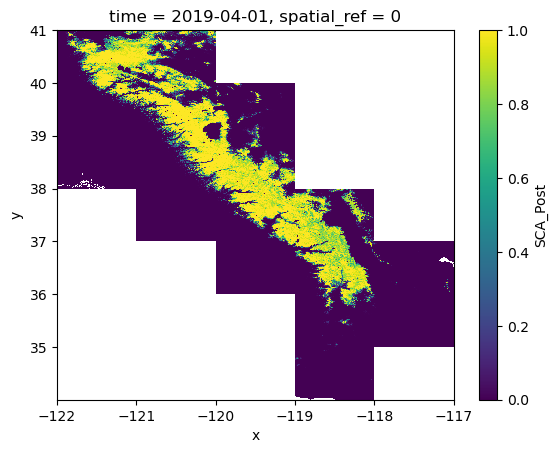

In [5]:
swe_sca_ds.SCA_Post.sel(time='04-01-2019').plot()

In [5]:
import datetime

def day_of_year(date):
    # Check if it's a leap year
    leap_year = date.year % 4 == 0 and (date.year % 100 != 0 or date.year % 400 == 0)
    
    # Define days in each month, accounting for leap year
    days_in_month = [31, 29 if leap_year else 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
    
    # Calculate day of the year
    day_count = sum(days_in_month[i] for i in range(date.month - 1)) + date.day
    
    return day_count

# Example usage
date = datetime.date(2024, 5, 9)
print("Day of the year:", day_of_year(date))

Day of the year: 130


In [6]:
#Add DOY and DOWY column
def add_dowy(df, col=None):
    print("Adding Day of Water Year (DOWY)")
    if col is None:
        df['doy'] = df.index.dayofyear
        df['decyear'] = Time(df.index).decimalyear
    else:
        df['doy'] = pd.to_datetime(df[col]).dt.dayofyear
        df['decyear'] = Time(pd.to_datetime(df[col])).decimalyear
    
    #df['dowy'] = (df['doy'].index - pd.DateOffset(months=9)).dayofyear
    # Sept 30 is doy 273
    df['dowy'] = df['doy'] - 273
    df.loc[df['dowy'] <= 0, 'dowy'] += 365

In [7]:
add_dowy(atl06sr_gdf)

Adding Day of Water Year (DOWY)


In [8]:
atl06sr_gdf.columns

Index(['segment_watermask', 'segment_snowcover', 'pflags', '3dep.value',
       'region', '3dep.deriv.slope', 'gt', 'n_fit_photons',
       'w_surface_window_final', '3dep.fileid', 'rgt', 'rms_misfit',
       '3dep.deriv.count', '3dep.deriv.aspect', 'h_mean', 'dh_fit_dx', 'x_atc',
       'h_sigma', 'spot', 'y_atc', 'urban_flag', '3dep.time_ns',
       'beam_azimuth', 'srcid', 'segment_landcover', 'cycle', 'photon_start',
       'geometry', 'time', 'slope_count', 'slope', 'aspect', 'file', 'value',
       'time_acq', 'doy', 'decyear', 'dowy'],
      dtype='object')

In [8]:
atl06sr_gdf['acqdate'] = atl06sr_gdf.index.date
atl06sr_gdf['acqdate_dt'] = pd.to_datetime(atl06sr_gdf['acqdate'])

In [11]:
atl06sr_gdf['acqdate'].unique()

array([datetime.date(2018, 10, 14), datetime.date(2018, 10, 15),
       datetime.date(2018, 10, 18), datetime.date(2018, 10, 19),
       datetime.date(2018, 10, 23), datetime.date(2018, 11, 4),
       datetime.date(2018, 11, 8), datetime.date(2018, 11, 9),
       datetime.date(2018, 11, 12), datetime.date(2018, 11, 13),
       datetime.date(2018, 11, 16), datetime.date(2018, 11, 17),
       datetime.date(2018, 11, 20), datetime.date(2018, 11, 25),
       datetime.date(2018, 12, 3), datetime.date(2018, 12, 7),
       datetime.date(2018, 12, 11), datetime.date(2018, 12, 12),
       datetime.date(2018, 12, 15), datetime.date(2018, 12, 16),
       datetime.date(2018, 12, 19), datetime.date(2019, 1, 1),
       datetime.date(2019, 1, 5), datetime.date(2019, 1, 6),
       datetime.date(2019, 1, 9), datetime.date(2019, 1, 10),
       datetime.date(2019, 1, 13), datetime.date(2019, 1, 14),
       datetime.date(2019, 1, 18), datetime.date(2019, 1, 21),
       datetime.date(2019, 1, 22), datetime

In [12]:
atl06sr_gdf.crs

<Geographic 3D CRS: EPSG:7912>
Name: ITRF2014
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
- h[up]: Ellipsoidal height (metre)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: International Terrestrial Reference Frame 2014
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [13]:
swe_sca_ds.rio.crs

CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]')

<Axes: title={'center': 'time = 2019-04-01, spatial_ref = 0'}, xlabel='x', ylabel='y'>

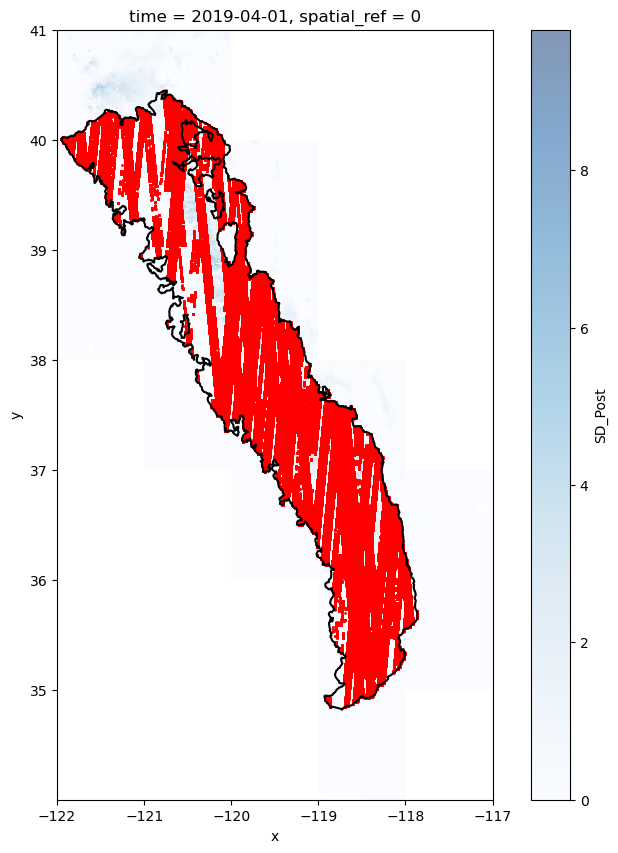

In [14]:
fig, ax = plt.subplots(figsize=(10,10))

swe_sca_ds.SD_Post.sel(time='2019-04-01').plot(ax=ax, cmap='Blues', alpha=0.5)
atl06sr_gdf[atl06sr_gdf.index.year==2019].plot(ax=ax, color='red', markersize=1)
sierras.boundary.plot(ax=ax, edgecolor='black', facecolor='none')

In [9]:
atl06sr_gdf['reanalysis_swe'] = np.nan
atl06sr_gdf['reanalysis_sca'] = np.nan
atl06sr_gdf['reanalysis_sd'] = np.nan

# write an efficient for loop to loop through each date from each year in the atl06sr_gdf and extract the swe, sca, sd values from the swe_sca_ds dataset and add them to the atl06sr_gdf as new columns  
for year in range(2018, 2022):
    print(f"Processing year: {year}")
    year_mask = atl06sr_gdf.index.year == year
    for date in atl06sr_gdf.loc[year_mask].index.normalize().unique():
        print(f"  Processing date: {date.date()}")
        date_mask = atl06sr_gdf.index.normalize() == date
        latitudes = xr.DataArray(atl06sr_gdf.loc[year_mask & date_mask].to_crs('epsg:4326').geometry.y.values, dims="points")
        longitudes = xr.DataArray(atl06sr_gdf.loc[year_mask & date_mask].to_crs('epsg:4326').geometry.x.values, dims="points")
        
        swe_values = swe_sca_ds['SWE_Post'].sel(
            time=date,
            y=latitudes,
            x=longitudes,
            method="nearest"
        ).values
        
        sca_values = swe_sca_ds['SCA_Post'].sel(
            time=date,
            y=latitudes,
            x=longitudes,
            method="nearest"
        ).values
        
        sd_values = swe_sca_ds['SD_Post'].sel(
            time=date,
            y=latitudes,
            x=longitudes,
            method="nearest"
        ).values
        
        atl06sr_gdf.loc[year_mask & date_mask, 'reanalysis_swe'] = swe_values
        atl06sr_gdf.loc[year_mask & date_mask, 'reanalysis_sca'] = sca_values
        atl06sr_gdf.loc[year_mask & date_mask, 'reanalysis_sd'] = sd_values

Processing year: 2018
  Processing date: 2018-10-14
  Processing date: 2018-10-15
  Processing date: 2018-10-18
  Processing date: 2018-10-19
  Processing date: 2018-10-23
  Processing date: 2018-11-04
  Processing date: 2018-11-08
  Processing date: 2018-11-09
  Processing date: 2018-11-12
  Processing date: 2018-11-13
  Processing date: 2018-11-16
  Processing date: 2018-11-17
  Processing date: 2018-11-20
  Processing date: 2018-11-25
  Processing date: 2018-12-03
  Processing date: 2018-12-07
  Processing date: 2018-12-11
  Processing date: 2018-12-12
  Processing date: 2018-12-15
  Processing date: 2018-12-16
  Processing date: 2018-12-19
Processing year: 2019
  Processing date: 2019-01-01
  Processing date: 2019-01-05
  Processing date: 2019-01-06
  Processing date: 2019-01-09
  Processing date: 2019-01-10
  Processing date: 2019-01-13
  Processing date: 2019-01-14
  Processing date: 2019-01-18
  Processing date: 2019-01-21
  Processing date: 2019-01-22
  Processing date: 2019-02

In [10]:
atl06sr_gdf['reanalysis_swe_linear'] = np.nan
atl06sr_gdf['reanalysis_sca_linear'] = np.nan
atl06sr_gdf['reanalysis_sd_linear'] = np.nan

# write an efficient for loop to loop through each date from each year in the atl06sr_gdf and extract the swe, sca, sd values from the swe_sca_ds dataset and add them to the atl06sr_gdf as new columns  
for year in range(2018, 2022):
    print(f"Processing year: {year}")
    year_mask = atl06sr_gdf.index.year == year
    for date in atl06sr_gdf.loc[year_mask].index.normalize().unique():
        print(f"  Processing date: {date.date()}")
        date_mask = atl06sr_gdf.index.normalize() == date
        latitudes = xr.DataArray(atl06sr_gdf.loc[year_mask & date_mask].to_crs('epsg:4326').geometry.y.values, dims="points")
        longitudes = xr.DataArray(atl06sr_gdf.loc[year_mask & date_mask].to_crs('epsg:4326').geometry.x.values, dims="points")
        
        swe_values = swe_sca_ds['SWE_Post'].sel(time=date).interp(
            y=latitudes,
            x=longitudes,
            method="linear"
        ).values
        
        sca_values = swe_sca_ds['SCA_Post'].sel(time=date).interp(
            y=latitudes,
            x=longitudes,
            method="linear"
        ).values
        
        sd_values = swe_sca_ds['SD_Post'].sel(time=date).interp(
            y=latitudes,
            x=longitudes,
            method="linear"
        ).values
        
        atl06sr_gdf.loc[year_mask & date_mask, 'reanalysis_swe_linear'] = swe_values
        atl06sr_gdf.loc[year_mask & date_mask, 'reanalysis_sca_linear'] = sca_values
        atl06sr_gdf.loc[year_mask & date_mask, 'reanalysis_sd_linear'] = sd_values

Processing year: 2018
  Processing date: 2018-10-14
  Processing date: 2018-10-15
  Processing date: 2018-10-18
  Processing date: 2018-10-19
  Processing date: 2018-10-23
  Processing date: 2018-11-04
  Processing date: 2018-11-08
  Processing date: 2018-11-09
  Processing date: 2018-11-12
  Processing date: 2018-11-13
  Processing date: 2018-11-16
  Processing date: 2018-11-17
  Processing date: 2018-11-20
  Processing date: 2018-11-25
  Processing date: 2018-12-03
  Processing date: 2018-12-07
  Processing date: 2018-12-11
  Processing date: 2018-12-12
  Processing date: 2018-12-15
  Processing date: 2018-12-16
  Processing date: 2018-12-19
Processing year: 2019
  Processing date: 2019-01-01
  Processing date: 2019-01-05
  Processing date: 2019-01-06
  Processing date: 2019-01-09
  Processing date: 2019-01-10
  Processing date: 2019-01-13
  Processing date: 2019-01-14
  Processing date: 2019-01-18
  Processing date: 2019-01-21
  Processing date: 2019-01-22
  Processing date: 2019-02

In [12]:
atl06sr_gdf['reanalysis_swe_cubic'] = np.nan
atl06sr_gdf['reanalysis_sca_cubic'] = np.nan
atl06sr_gdf['reanalysis_sd_cubic'] = np.nan

# write an efficient for loop to loop through each date from each year in the atl06sr_gdf and extract the swe, sca, sd values from the swe_sca_ds dataset and add them to the atl06sr_gdf as new columns  
for year in range(2018, 2022):
    print(f"Processing year: {year}")
    year_mask = atl06sr_gdf.index.year == year
    for date in atl06sr_gdf.loc[year_mask].index.normalize().unique():
        print(f"  Processing date: {date.date()}")
        date_mask = atl06sr_gdf.index.normalize() == date
        latitudes = xr.DataArray(atl06sr_gdf.loc[year_mask & date_mask].to_crs('epsg:4326').geometry.y.values, dims="points")
        longitudes = xr.DataArray(atl06sr_gdf.loc[year_mask & date_mask].to_crs('epsg:4326').geometry.x.values, dims="points")
        
        # Fill NaN values with 0 before cubic interpolation to avoid ValueError
        swe_values = swe_sca_ds['SWE_Post'].sel(time=date).fillna(0).interp(
            y=latitudes,
            x=longitudes,
            method="cubic"
        ).values
        
        sca_values = swe_sca_ds['SCA_Post'].sel(time=date).fillna(0).interp(
            y=latitudes,
            x=longitudes,
            method="cubic"
        ).values
        
        sd_values = swe_sca_ds['SD_Post'].sel(time=date).fillna(0).interp(
            y=latitudes,
            x=longitudes,
            method="cubic"
        ).values
        
        atl06sr_gdf.loc[year_mask & date_mask, 'reanalysis_swe_cubic'] = swe_values
        atl06sr_gdf.loc[year_mask & date_mask, 'reanalysis_sca_cubic'] = sca_values
        atl06sr_gdf.loc[year_mask & date_mask, 'reanalysis_sd_cubic'] = sd_values

Processing year: 2018
  Processing date: 2018-10-14
  Processing date: 2018-10-15
  Processing date: 2018-10-18
  Processing date: 2018-10-19
  Processing date: 2018-10-23
  Processing date: 2018-11-04
  Processing date: 2018-11-08
  Processing date: 2018-11-09
  Processing date: 2018-11-12
  Processing date: 2018-11-13
  Processing date: 2018-11-16
  Processing date: 2018-11-17
  Processing date: 2018-11-20
  Processing date: 2018-11-25
  Processing date: 2018-12-03
  Processing date: 2018-12-07
  Processing date: 2018-12-11
  Processing date: 2018-12-12
  Processing date: 2018-12-15
  Processing date: 2018-12-16
  Processing date: 2018-12-19
Processing year: 2019
  Processing date: 2019-01-01
  Processing date: 2019-01-05
  Processing date: 2019-01-06
  Processing date: 2019-01-09
  Processing date: 2019-01-10
  Processing date: 2019-01-13
  Processing date: 2019-01-14
  Processing date: 2019-01-18
  Processing date: 2019-01-21
  Processing date: 2019-01-22
  Processing date: 2019-02

In [16]:
atl06sr_gdf.columns

Index(['pflags', 'x_atc', 'h_mean', 'gt', 'dh_fit_dx', 'n_fit_photons', 'spot',
       'region', 'cycle', 'h_sigma', 'w_surface_window_final', 'rgt',
       'segment_id', 'y_atc', 'rms_misfit', 'geometry', 'segment_snowcover',
       'segment_landcover', 'beam_azimuth', 'segment_watermask', 'urban_flag',
       '3dep.aspect', '3dep.flags', '3dep.time', '3dep.count', '3dep.value',
       '3dep.slope', '3dep.file_id', 'water_year', 'doy', 'decyear', 'dowy',
       'acqdate', 'acqdate_dt', 'reanalysis_swe', 'reanalysis_sca',
       'reanalysis_sd', 'reanalysis_swe_linear', 'reanalysis_sca_linear',
       'reanalysis_sd_linear', 'reanalysis_swe_cubic', 'reanalysis_sca_cubic',
       'reanalysis_sd_cubic'],
      dtype='object')

In [17]:
atl06sr_gdf['icesat2_3dep_dif'] = atl06sr_gdf['h_mean'] - atl06sr_gdf['3dep.value']

In [18]:
# Compare interpolation methods for points with high snow cover (SCA > 0.9)
# Each method uses its corresponding SCA mask
from scipy import stats

# Define the three reanalysis SD columns and their corresponding SCA columns
sd_columns = ['reanalysis_sd', 'reanalysis_sd_linear', 'reanalysis_sd_cubic']
sca_columns = ['reanalysis_sca', 'reanalysis_sca_linear', 'reanalysis_sca_cubic']
method_names = ['Nearest Neighbor', 'Bilinear', 'Cubic']

# Calculate metrics for each method using its own SCA mask
results = []
for sd_col, sca_col, name in zip(sd_columns, sca_columns, method_names):
    # Use the corresponding SCA column for masking
    snow_mask = atl06sr_gdf[sca_col] > 0.9
    
    # Get the observed snow depth proxy (ICESat-2 minus 3DEP)
    observed = atl06sr_gdf.loc[snow_mask, 'icesat2_3dep_dif']
    predicted = atl06sr_gdf.loc[snow_mask, sd_col]
    
    # Remove NaN pairs
    valid_mask = ~(np.isnan(observed) | np.isnan(predicted))
    obs_valid = observed[valid_mask]
    pred_valid = predicted[valid_mask]
    
    # Calculate metrics
    n = len(obs_valid)
    bias = np.mean(obs_valid - pred_valid)
    mae = np.mean(np.abs(obs_valid - pred_valid))
    rmse = np.sqrt(np.mean((obs_valid - pred_valid)**2))
    r, p_value = stats.pearsonr(obs_valid, pred_valid)
    
    results.append({
        'Method': name,
        'N': n,
        'Bias (m)': bias,
        'MAE (m)': mae,
        'RMSE (m)': rmse,
        'R': r,
        'p-value': p_value
    })

# Create a DataFrame with results
metrics_df = pd.DataFrame(results)
print("Comparison of interpolation methods (each using its own SCA > 0.9 mask)")
print("=" * 75)
print(metrics_df.to_string(index=False))
print("\nNote: Comparing ICESat-2 minus 3DEP elevation difference to reanalysis snow depth")

Comparison of interpolation methods (each using its own SCA > 0.9 mask)
          Method       N  Bias (m)  MAE (m)  RMSE (m)        R  p-value
Nearest Neighbor 1013013 -0.412705 1.484202  2.209406 0.361335      0.0
        Bilinear  948182 -0.374754 1.459971  2.166826 0.364076      0.0
           Cubic  980499 -0.400860 1.474769  2.187259 0.362095      0.0

Note: Comparing ICESat-2 minus 3DEP elevation difference to reanalysis snow depth


In [19]:
atl06sr_gdf.columns

Index(['pflags', 'x_atc', 'h_mean', 'gt', 'dh_fit_dx', 'n_fit_photons', 'spot',
       'region', 'cycle', 'h_sigma', 'w_surface_window_final', 'rgt',
       'segment_id', 'y_atc', 'rms_misfit', 'geometry', 'segment_snowcover',
       'segment_landcover', 'beam_azimuth', 'segment_watermask', 'urban_flag',
       '3dep.aspect', '3dep.flags', '3dep.time', '3dep.count', '3dep.value',
       '3dep.slope', '3dep.file_id', 'water_year', 'doy', 'decyear', 'dowy',
       'acqdate', 'acqdate_dt', 'reanalysis_swe', 'reanalysis_sca',
       'reanalysis_sd', 'reanalysis_swe_linear', 'reanalysis_sca_linear',
       'reanalysis_sd_linear', 'reanalysis_swe_cubic', 'reanalysis_sca_cubic',
       'reanalysis_sd_cubic', 'icesat2_3dep_dif'],
      dtype='object')

In [20]:
atl06sr_gdf = atl06sr_gdf.drop(columns=['reanalysis_swe', 'reanalysis_sca', 'reanalysis_sd', 'reanalysis_swe_cubic', 'reanalysis_sca_cubic', 'reanalysis_sd_cubic'])

In [21]:
atl06sr_gdf.columns

Index(['pflags', 'x_atc', 'h_mean', 'gt', 'dh_fit_dx', 'n_fit_photons', 'spot',
       'region', 'cycle', 'h_sigma', 'w_surface_window_final', 'rgt',
       'segment_id', 'y_atc', 'rms_misfit', 'geometry', 'segment_snowcover',
       'segment_landcover', 'beam_azimuth', 'segment_watermask', 'urban_flag',
       '3dep.aspect', '3dep.flags', '3dep.time', '3dep.count', '3dep.value',
       '3dep.slope', '3dep.file_id', 'water_year', 'doy', 'decyear', 'dowy',
       'acqdate', 'acqdate_dt', 'reanalysis_swe_linear',
       'reanalysis_sca_linear', 'reanalysis_sd_linear', 'icesat2_3dep_dif'],
      dtype='object')

In [22]:
atl06sr_gdf = atl06sr_gdf.rename(columns={'reanalysis_swe_linear': 'reanalysis_swe', 'reanalysis_sca_linear': 'reanalysis_sca', 'reanalysis_sd_linear': 'reanalysis_sd'})

In [16]:
atl06sr_gdf.loc[atl06sr_gdf.index.year==2021]

,pflags,x_atc,h_mean,gt,dh_fit_dx,n_fit_photons,spot,region,cycle,h_sigma,...,3dep.file_id,water_year,doy,decyear,dowy,acqdate,acqdate_dt,reanalysis_swe,reanalysis_sca,reanalysis_sd
time,,,,,,,,,,,,,,,,,,,,,
2021-01-04 20:47:27.356191744,0,15804643.0,2256.394233,10,-0.127011,18,1,region_3,10,0.104476,...,42949672960,wy2021,4,2021.010593,96,2021-01-04,2021-01-04,0.0018,0.6836,0.007
2021-01-04 20:47:27.358982144,0,15804663.0,2254.284357,10,-0.056083,29,1,region_3,10,0.064426,...,42949672960,wy2021,4,2021.010593,96,2021-01-04,2021-01-04,0.0018,0.6836,0.007
2021-01-04 20:47:27.361776128,0,15804683.0,2253.329449,10,-0.007196,52,1,region_3,10,0.043361,...,42949672960,wy2021,4,2021.010593,96,2021-01-04,2021-01-04,0.0018,0.6836,0.007
2021-01-04 20:47:27.364574976,0,15804703.0,2253.363628,10,0.012932,84,1,region_3,10,0.021871,...,42949672960,wy2021,4,2021.010593,96,2021-01-04,2021-01-04,0.0018,0.6836,0.007
2021-01-04 20:47:27.367380736,0,15804723.0,2253.629602,10,0.015198,89,1,region_3,10,0.027811,...,42949672960,wy2021,4,2021.010593,96,2021-01-04,2021-01-04,0.0018,0.6836,0.007
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-09-30 07:56:02.104347136,0,16052711.0,226.890584,40,-0.054218,20,3,region_1_south,13,0.076027,...,73014444032,wy2021,273,2021.746111,365,2021-09-30,2021-09-30,0.0000,0.0000,0.000
2021-09-30 07:56:02.107133952,0,16052731.0,225.671663,40,-0.069895,20,3,region_1_south,13,0.065225,...,73014444032,wy2021,273,2021.746111,365,2021-09-30,2021-09-30,0.0000,0.0000,0.000
2021-09-30 07:56:02.109926144,0,16052751.0,224.486863,40,-0.044743,16,3,region_1_south,13,0.051071,...,73014444032,wy2021,273,2021.746111,365,2021-09-30,2021-09-30,0.0000,0.0000,0.000


Text(0.5, 1.0, 'ICESat-2 points')

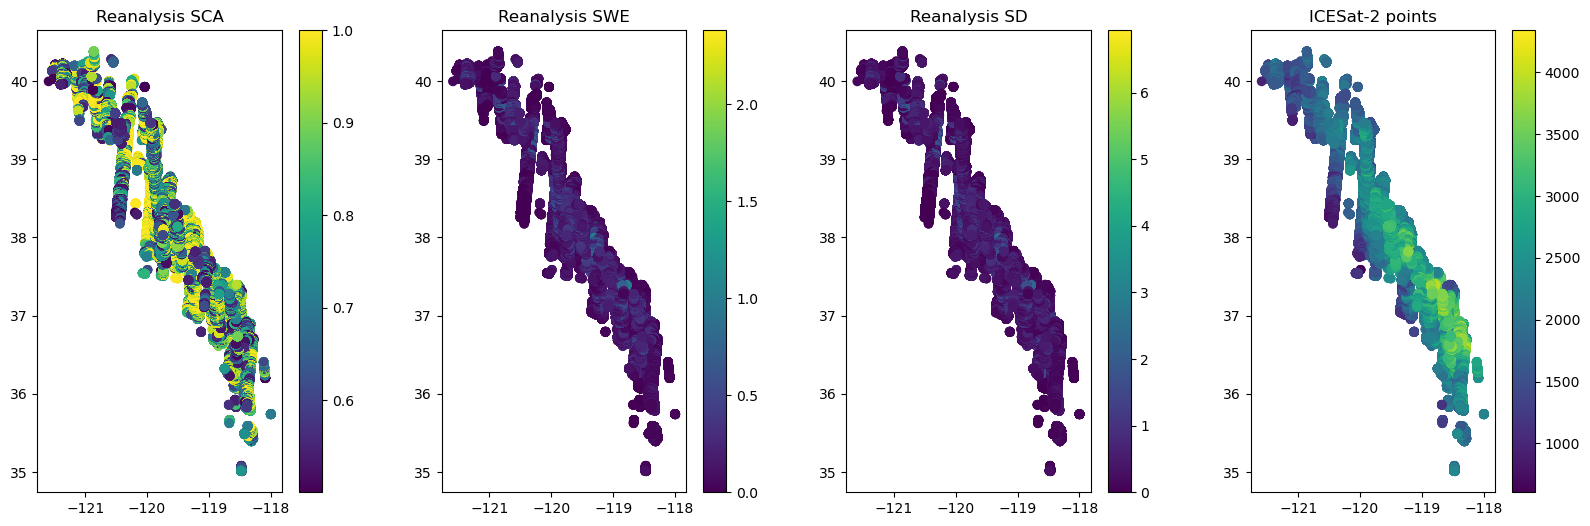

In [19]:
fig, ax = plt.subplots(1,4, figsize=(20,6))
atl06sr_gdf.loc[(atl06sr_gdf.index.year==2021) & (atl06sr_gdf['reanalysis_sca']>0.5)].plot(ax=ax[0], column='reanalysis_sca', legend=True)
ax[0].set_title('Reanalysis SCA')
atl06sr_gdf.loc[(atl06sr_gdf.index.year==2021) & (atl06sr_gdf['reanalysis_sca']>0.5)].plot(ax=ax[1], column='reanalysis_swe', legend=True)
ax[1].set_title('Reanalysis SWE')
atl06sr_gdf.loc[(atl06sr_gdf.index.year==2021) & (atl06sr_gdf['reanalysis_sca']>0.5)].plot(ax=ax[2], column='reanalysis_sd', legend=True)
ax[2].set_title('Reanalysis SD')
atl06sr_gdf.loc[(atl06sr_gdf.index.year==2021) & (atl06sr_gdf['reanalysis_sca']>0.5)].plot(ax=ax[3], column='h_mean', legend=True)
ax[3].set_title('ICESat-2 points')

Text(0.5, 1.0, 'ICESat-2 points')

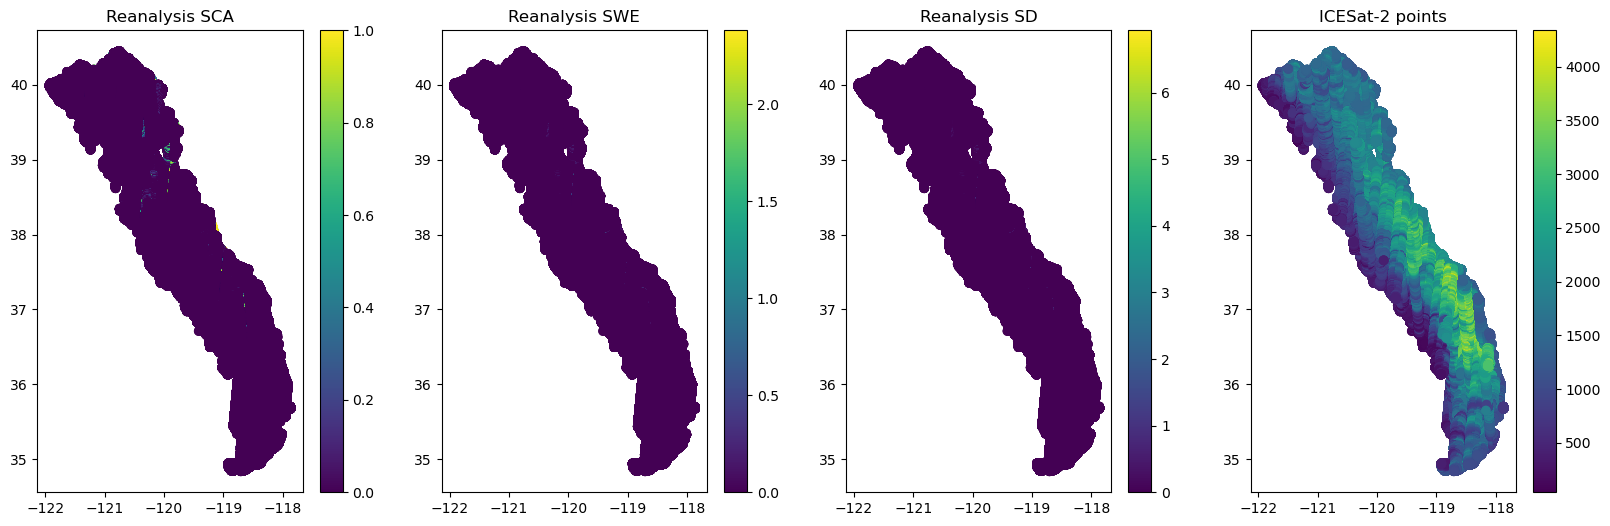

In [ ]:
fig, ax = plt.subplots(1,4, figsize=(20,6))
atl06sr_gdf.loc[(atl06sr_gdf.index.year==2021)].plot(ax=ax[0], column='reanalysis_sca', legend=True)
ax[0].set_title('Reanalysis SCA')
atl06sr_gdf.loc[(atl06sr_gdf.index.year==2021)].plot(ax=ax[1], column='reanalysis_swe', legend=True)
ax[1].set_title('Reanalysis SWE')
atl06sr_gdf.loc[(atl06sr_gdf.index.year==2021)].plot(ax=ax[2], column='reanalysis_sd', legend=True)
ax[2].set_title('Reanalysis SD')
atl06sr_gdf.loc[(atl06sr_gdf.index.year==2021)].plot(ax=ax[3], column='h_mean', legend=True)
ax[3].set_title('ICESat-2 points')

Text(0.5, 1.0, 'ICESat-2 points')

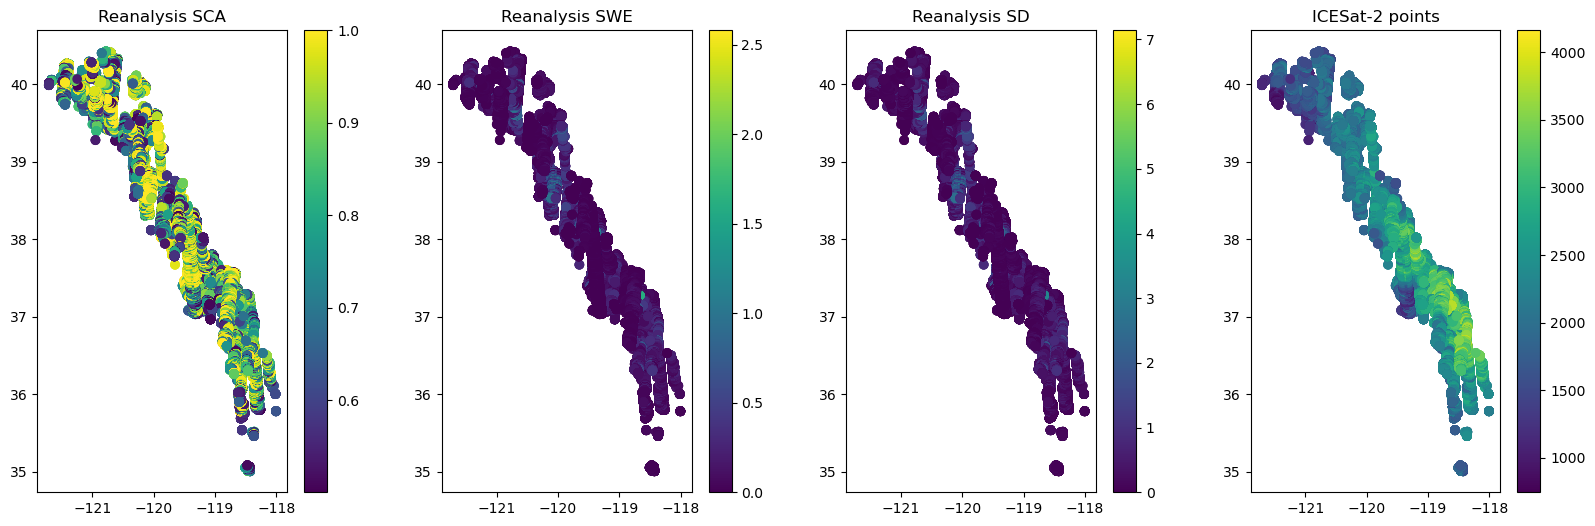

In [17]:
fig, ax = plt.subplots(1,4, figsize=(20,6))
atl06sr_gdf.loc[(atl06sr_gdf.index.year==2020) & (atl06sr_gdf['reanalysis_sca']>0.5)].plot(ax=ax[0], column='reanalysis_sca', legend=True)
ax[0].set_title('Reanalysis SCA')
atl06sr_gdf.loc[(atl06sr_gdf.index.year==2020) & (atl06sr_gdf['reanalysis_sca']>0.5)].plot(ax=ax[1], column='reanalysis_swe', legend=True)
ax[1].set_title('Reanalysis SWE')
atl06sr_gdf.loc[(atl06sr_gdf.index.year==2020) & (atl06sr_gdf['reanalysis_sca']>0.5)].plot(ax=ax[2], column='reanalysis_sd', legend=True)
ax[2].set_title('Reanalysis SD')
atl06sr_gdf.loc[(atl06sr_gdf.index.year==2020) & (atl06sr_gdf['reanalysis_sca']>0.5)].plot(ax=ax[3], column='h_mean', legend=True)
ax[3].set_title('ICESat-2 points')

Text(0.5, 1.0, 'ICESat-2 points')

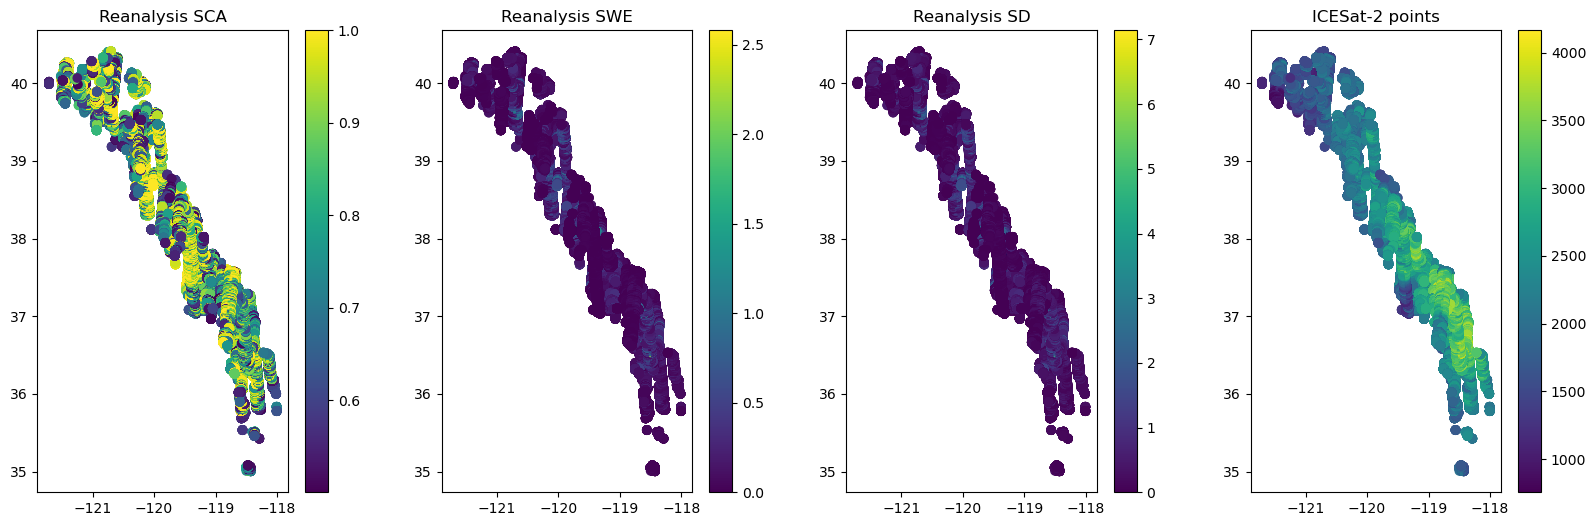

In [20]:
fig, ax = plt.subplots(1,4, figsize=(20,6))
atl06sr_gdf.loc[(atl06sr_gdf.index.year==2020) & (atl06sr_gdf['reanalysis_sca']>0.5)].plot(ax=ax[0], column='reanalysis_sca', legend=True)
ax[0].set_title('Reanalysis SCA')
atl06sr_gdf.loc[(atl06sr_gdf.index.year==2020) & (atl06sr_gdf['reanalysis_sca']>0.5)].plot(ax=ax[1], column='reanalysis_swe', legend=True)
ax[1].set_title('Reanalysis SWE')
atl06sr_gdf.loc[(atl06sr_gdf.index.year==2020) & (atl06sr_gdf['reanalysis_sca']>0.5)].plot(ax=ax[2], column='reanalysis_sd', legend=True)
ax[2].set_title('Reanalysis SD')
atl06sr_gdf.loc[(atl06sr_gdf.index.year==2020) & (atl06sr_gdf['reanalysis_sca']>0.5)].plot(ax=ax[3], column='h_mean', legend=True)
ax[3].set_title('ICESat-2 points')

Text(0.5, 1.0, 'ICESat-2 points')

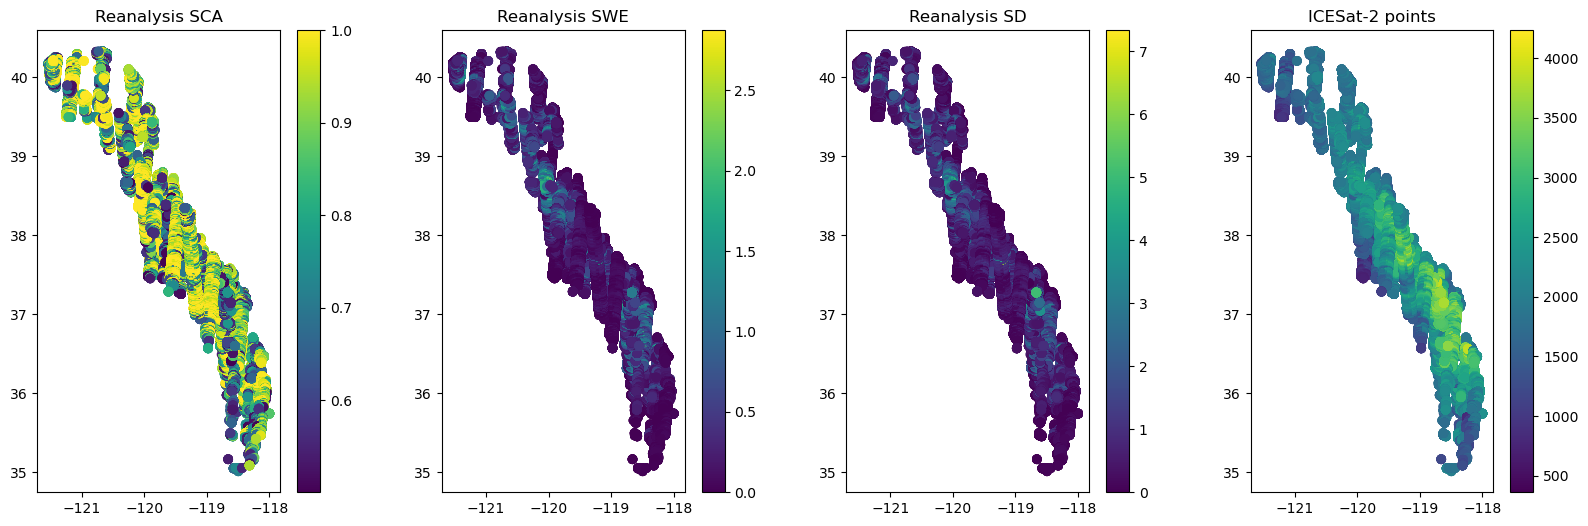

In [23]:
fig, ax = plt.subplots(1,4, figsize=(20,6))
atl06sr_gdf.loc[(atl06sr_gdf.index.year==2019) & (atl06sr_gdf['reanalysis_sca']>0.5)].plot(ax=ax[0], column='reanalysis_sca', legend=True)
ax[0].set_title('Reanalysis SCA')
atl06sr_gdf.loc[(atl06sr_gdf.index.year==2019) & (atl06sr_gdf['reanalysis_sca']>0.5)].plot(ax=ax[1], column='reanalysis_swe', legend=True)
ax[1].set_title('Reanalysis SWE')
atl06sr_gdf.loc[(atl06sr_gdf.index.year==2019) & (atl06sr_gdf['reanalysis_sca']>0.5)].plot(ax=ax[2], column='reanalysis_sd', legend=True)
ax[2].set_title('Reanalysis SD')
atl06sr_gdf.loc[(atl06sr_gdf.index.year==2019) & (atl06sr_gdf['reanalysis_sca']>0.5)].plot(ax=ax[3], column='h_mean', legend=True)
ax[3].set_title('ICESat-2 points')

Text(0.5, 1.0, 'ICESat-2 points')

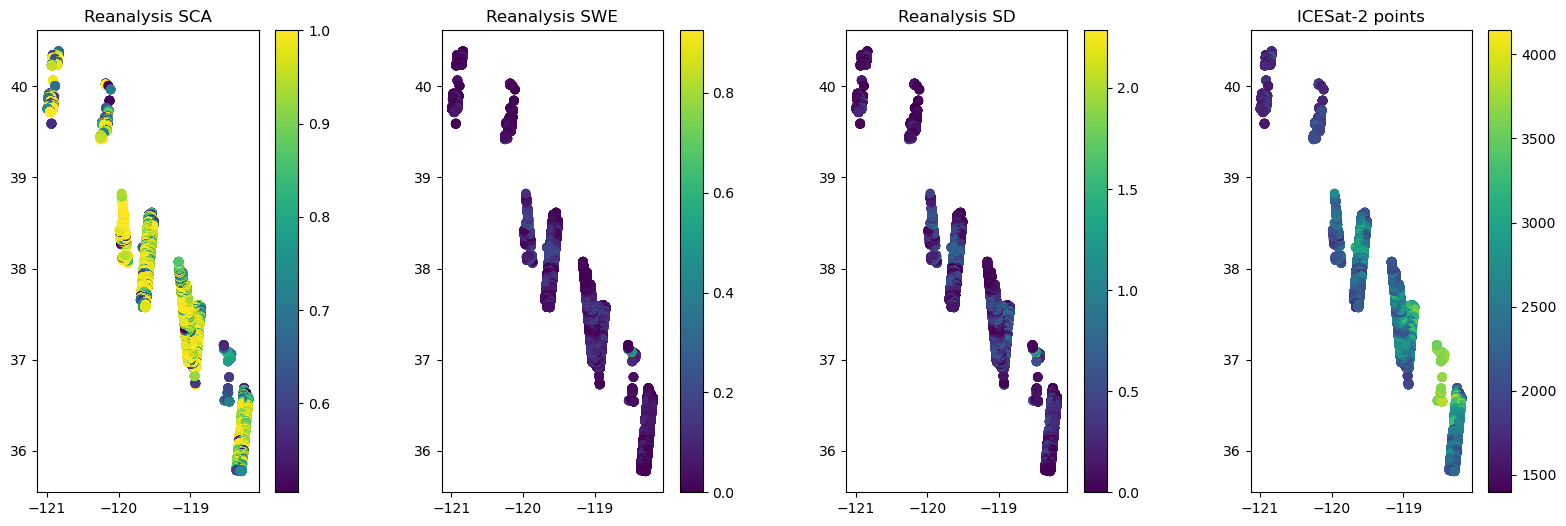

In [24]:
fig, ax = plt.subplots(1,4, figsize=(20,6))
atl06sr_gdf.loc[(atl06sr_gdf.index.year==2018) & (atl06sr_gdf['reanalysis_sca']>0.5)].plot(ax=ax[0], column='reanalysis_sca', legend=True)
ax[0].set_title('Reanalysis SCA')
atl06sr_gdf.loc[(atl06sr_gdf.index.year==2018) & (atl06sr_gdf['reanalysis_sca']>0.5)].plot(ax=ax[1], column='reanalysis_swe', legend=True)
ax[1].set_title('Reanalysis SWE')
atl06sr_gdf.loc[(atl06sr_gdf.index.year==2018) & (atl06sr_gdf['reanalysis_sca']>0.5)].plot(ax=ax[2], column='reanalysis_sd', legend=True)
ax[2].set_title('Reanalysis SD')
atl06sr_gdf.loc[(atl06sr_gdf.index.year==2018) & (atl06sr_gdf['reanalysis_sca']>0.5)].plot(ax=ax[3], column='h_mean', legend=True)
ax[3].set_title('ICESat-2 points')

In [21]:
atl06sr_gdf['icesat2_3dep_dif'] = atl06sr_gdf['h_mean'] - atl06sr_gdf['3dep.value']

In [20]:
np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']==0), 'icesat2_3dep_dif'])

np.float64(-0.054728642373447656)

In [19]:
atl06sr_gdf['dif_plus'] = atl06sr_gdf['icesat2_3dep_dif'] - np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']==0), 'icesat2_3dep_dif'])

In [21]:
atl06sr_gdf['offset_sd'] = atl06sr_gdf['dif_plus'] - atl06sr_gdf['reanalysis_sd']

### Save the file:

In [23]:
atl06sr_gdf.to_pickle('../data/icesat2/sierras_gdf_2018_2021_atl06_01312026_processed.pkl')

### Now make the fsca mask:

In [25]:
# use open_mfdataset to open all years of swe/sca data at once, then open all sd data at once, and merge the two datasets saving the output file

base_dir = '../swe_reanalysis_pca/data/download'

swe_sca_files = []
sd_files = []

for year in range(1985, 2022):
    year_folder = Path(base_dir) / str(year)
    swe_sca_files.append(f"{base_dir}/{year}/SWE_SCA_POST_{year}.nc")
    sd_files.append(f"{base_dir}/{year}/SD_POST_{year}.nc")

def preprocess_swe(ds):
    ds = ds.rename({'Latitude': 'y', 'Longitude': 'x'})
    ds = ds.rio.set_spatial_dims('y', 'x', inplace=True)
    return ds

swe_sca_ds_allyrs = xr.open_mfdataset(
    swe_sca_files,
    combine='by_coords',
    preprocess=preprocess_swe
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)


sd_ds_allyrs = xr.open_mfdataset(
    sd_files,
    combine='by_coords'
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)

swe_sca_ds_allyrs['SD_Post'] = sd_ds_allyrs['SD_Post']


# swe_sca_ds = swe_sca_ds.rename({'Latitude': 'y', 'Longitude': 'x'})
# swe_sca_ds = swe_sca_ds.rio.set_spatial_dims('y', 'x', inplace=True)
swe_sca_ds_allyrs['SWE_Post'] = swe_sca_ds_allyrs['SWE_Post'].T
swe_sca_ds_allyrs['SCA_Post'] = swe_sca_ds_allyrs['SCA_Post'].T
swe_sca_ds_allyrs = swe_sca_ds_allyrs.transpose('time', 'y', 'x')
swe_sca_ds_allyrs.rio.write_crs('EPSG:4326', inplace=True)
#swe_sca_ds['SD_Post'] = swe_sca_ds['SD_Post'].T

<xarray.Dataset> Size: 287GB
Dimensions:      (time: 13514, y: 1575, x: 1125)
Coordinates:
  * y            (y) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * x            (x) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
  * time         (time) datetime64[ns] 108kB 1984-10-01 ... 2021-09-30
    spatial_ref  int64 8B 0
Data variables:
    SWE_Post     (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SCA_Post     (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SD_Post      (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>

### Get timeseries of median/average reanalysis snow depth:

In [26]:
swe_sca_ds = swe_sca_ds.rename({'y': 'lat', 'x': 'lon'})

In [27]:
swe_sca_ds_allyrs = swe_sca_ds_allyrs.rename({'y': 'lat', 'x': 'lon'})

In [28]:
# 1. Select April 1 of each year
swe_sca_ds_allyrs_april1 = swe_sca_ds_allyrs.sel(time=( (swe_sca_ds_allyrs['time'].dt.month == 4) & (swe_sca_ds_allyrs['time'].dt.day == 1) ))

In [29]:
# 2. Compute mean April 1 snow depth across years
swe_sca_ds_allyrs_april1 = swe_sca_ds_allyrs_april1.mean(dim='time', skipna=True)

In [30]:
# 3. Threshold mask
mask = swe_sca_ds_allyrs_april1.SCA_Post > 0.5

In [31]:
mask_da = mask.astype(np.int32)

In [32]:
latitudes = xr.DataArray(atl06sr_gdf.to_crs('epsg:4326').geometry.y.values, dims="points")
longitudes = xr.DataArray(atl06sr_gdf.to_crs('epsg:4326').geometry.x.values, dims="points")

In [33]:
#atl06sr_gdf['mask'] = np.nan

sampled_mask = mask_da.sel(lat=latitudes, lon=longitudes, method='nearest').values

In [34]:
atl06sr_gdf['mask'] = sampled_mask

In [35]:
atl06sr_gdf.to_pickle('../data/icesat2/sierras_gdf_2018_2021_atl06_01312026_processed_masked.pkl')